### Loading the data frame with the variables for regresion model

In [2]:

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

data_dir_candidates = [
    Path("experiments/Regression/data"),
    Path("data"),
]
DATA_DIR = next((path for path in data_dir_candidates if path.exists()), None)

csv_files = sorted(DATA_DIR.rglob("replicate_results_*.csv"))

dfs = []
for csv_file in csv_files:
    df = pd.read_csv(csv_file)
    df["source_file"] = csv_file.name
    dfs.append(df)

print(f"Found {len(dfs)} condition files in {DATA_DIR.resolve()}:")
for csv_file in csv_files:
    print(f"- {csv_file.name}")

master_df = pd.concat(dfs, ignore_index=True)
master_df.to_csv(DATA_DIR / "master_results.csv", index=False)
master_df


Found 18 condition files in C:\Users\gmm71\OneDrive - University of Cambridge\Documents\Emulation models\abm-epidemic-emulator\experiments\Regression\data:
- replicate_results_LHS_to_LHS_aug0.csv
- replicate_results_LHS_to_LHS_aug1.csv
- replicate_results_LHS_to_MCMC_aug0.csv
- replicate_results_LHS_to_MCMC_aug1.csv
- replicate_results_LHS_to_UNIFORM_RANDOM_aug0.csv
- replicate_results_LHS_to_UNIFORM_RANDOM_aug1.csv
- replicate_results_MCMC_to_LHS_aug0.csv
- replicate_results_MCMC_to_LHS_aug1.csv
- replicate_results_MCMC_to_MCMC_aug0.csv
- replicate_results_MCMC_to_MCMC_aug1.csv
- replicate_results_MCMC_to_UNIFORM_RANDOM_aug0.csv
- replicate_results_MCMC_to_UNIFORM_RANDOM_aug1.csv
- replicate_results_UNIFORM_RANDOM_to_LHS_aug0.csv
- replicate_results_UNIFORM_RANDOM_to_LHS_aug1.csv
- replicate_results_UNIFORM_RANDOM_to_MCMC_aug0.csv
- replicate_results_UNIFORM_RANDOM_to_MCMC_aug1.csv
- replicate_results_UNIFORM_RANDOM_to_UNIFORM_RANDOM_aug0.csv
- replicate_results_UNIFORM_RANDOM_to_UNIF

,replicate_id,train_strategy,test_strategy,augmentation,in_domain,n_train_simulations,relative_MAE_I,R2_I,MAE_I,R2_S,...,MAE_S,MAE_R,RMSE,MSE,mean_peak_I,n_test_samples,model_path,training_epoch,source_file,peak_I
0,1,LHS,LHS,0,0,2800,6.2988,0.935098,163.2279,0.985955,...,1559.2844,1559.6222,2237.8757,5008087.50,4015.44,600,experiments\lhs-sampling\out\results\testing\l...,99,replicate_results_LHS_to_LHS_aug0.csv,NaN
1,2,LHS,LHS,0,0,2800,6.6589,0.937894,158.8861,0.986880,...,1534.6743,1525.9868,2153.0298,4635537.50,4015.44,600,experiments\lhs-sampling\out\results\testing\l...,96,replicate_results_LHS_to_LHS_aug0.csv,NaN
2,3,LHS,LHS,0,0,2800,6.3992,0.936721,155.7145,0.986076,...,1490.1917,1475.8263,2212.3149,4894337.00,4015.44,600,experiments\lhs-sampling\out\results\testing\l...,94,replicate_results_LHS_to_LHS_aug0.csv,NaN
3,4,LHS,LHS,0,0,2800,6.6328,0.937746,156.9570,0.986406,...,1467.7682,1454.2513,2183.0349,4765641.50,4015.44,600,experiments\lhs-sampling\out\results\testing\l...,99,replicate_results_LHS_to_LHS_aug0.csv,NaN
4,5,LHS,LHS,0,0,2800,6.7951,0.933664,161.0186,0.986697,...,1463.4814,1449.3961,2164.9404,4686967.00,4015.44,600,experiments\lhs-sampling\out\results\testing\l...,98,replicate_results_LHS_to_LHS_aug0.csv,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,6,UNIFORM_RANDOM,UNIFORM_RANDOM,1,0,8400,4.4279,0.958464,141.6713,0.990740,...,1254.8110,1226.2889,1877.0487,3523312.00,4476.45,600,experiments\random-sampling\out\trained models...,100,replicate_results_UNIFORM_RANDOM_to_UNIFORM_RA...,NaN
176,7,UNIFORM_RANDOM,UNIFORM_RANDOM,1,0,8400,4.3698,0.962265,131.4522,0.991901,...,1092.2500,1074.4663,1761.5143,3102932.50,4476.45,600,experiments\random-sampling\out\trained models...,100,replicate_results_UNIFORM_RANDOM_to_UNIFORM_RA...,NaN
177,8,UNIFORM_RANDOM,UNIFORM_RANDOM,1,0,8400,4.2783,0.957199,138.9727,0.990851,...,1316.8821,1290.1155,1867.6126,3487976.75,4476.45,600,experiments\random-sampling\out\trained models...,100,replicate_results_UNIFORM_RANDOM_to_UNIFORM_RA...,NaN
178,9,UNIFORM_RANDOM,UNIFORM_RANDOM,1,0,8400,4.2387,0.961638,132.6006,0.991374,...,1140.0293,1128.9860,1825.9504,3334095.00,4476.45,600,experiments\random-sampling\out\trained models...,100,replicate_results_UNIFORM_RANDOM_to_UNIFORM_RA...,NaN


In [3]:
master_df.shape
master_df.columns
master_df.isnull().sum()
master_df.describe()

master_df['condition_id'] = (
    master_df['train_strategy'] + '_' +
    master_df['test_strategy']  + '_' +
    master_df['augmentation'].astype(str)
)

master_df.tail()
master_cv=master_df.to_csv(DATA_DIR / "master_results.csv", index=False)

#### Regression Analysis using the ordinary regression method

In [12]:
from sklearn.linear_model import LinearRegression
import patsy
import statsmodels.api as sm
import os

import numpy as np
OUT_DIR = "Analysis_plots"
os.makedirs(OUT_DIR, exist_ok=True)

# Ensure condition_id and log targets exist regardless of cell execution order
if 'condition_id' not in master_df.columns:
    master_df['condition_id'] = (
        master_df['train_strategy'] + '_' +
        master_df['test_strategy']  + '_' +
        master_df['augmentation'].astype(str)
    )
if 'log_relative_MAE_I' not in master_df.columns:
    master_df['log_relative_MAE_I'] = np.log(master_df['relative_MAE_I'])

regresion_model = ('log_relative_MAE_I '
    '~ C(train_strategy, Treatment("LHS"))'
    '+ C(test_strategy, Treatment("LHS")) '
    '+ augmentation'
    '+train_strategy:augmentation'
    
   
)

y_mat, X_mat = patsy.dmatrices(regresion_model, data=master_df, return_type='dataframe')

ols_model = sm.OLS(y_mat, X_mat).fit()
print(ols_model.summary())
with open(os.path.join(OUT_DIR, "ordinary_regression_method_summary.txt"), "w") as f:
    f.write(ols_model.summary().as_text())



                            OLS Regression Results                            
Dep. Variable:     log_relative_MAE_I   R-squared:                       0.924
Model:                            OLS   Adj. R-squared:                  0.921
Method:                 Least Squares   F-statistic:                     298.3
Date:                Thu, 16 Jul 2026   Prob (F-statistic):           1.14e-92
Time:                        09:00:21   Log-Likelihood:                 255.62
No. Observations:                 180   AIC:                            -495.2
Df Residuals:                     172   BIC:                            -469.7
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                                            coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------

#### Regression analysis with cluster-robust

In [5]:
from sklearn.linear_model import LinearRegression
import patsy
import statsmodels.api as sm
import pandas as pd
import numpy as np
import os

OUT_DIR = "Analysis_plots"
os.makedirs(OUT_DIR, exist_ok=True)

# Ensure condition_id and log targets exist regardless of cell execution order
if 'condition_id' not in master_df.columns:
    master_df['condition_id'] = (
        master_df['train_strategy'] + '_' +
        master_df['test_strategy']  + '_' +
        master_df['augmentation'].astype(str)
    )
if 'log_relative_MAE_I' not in master_df.columns:
    master_df['log_relative_MAE_I'] = np.log(master_df['relative_MAE_I'])

regresion_model_cluster = ('log_relative_MAE_I '
    '~ C(train_strategy, Treatment("LHS"))'
    '+ C(test_strategy, Treatment("LHS")) '
    '+ augmentation' 
    '+train_strategy:augmentation'
    

)

y_mat_c, X_mat_c = patsy.dmatrices(regresion_model_cluster, data=master_df, return_type='dataframe')

ols_model_cluster = sm.OLS(y_mat_c, X_mat_c).fit()
model_robust = ols_model_cluster.get_robustcov_results(
    cov_type='cluster',
    groups=master_df['condition_id']
)
print(model_robust.summary())

coef_names = ols_model_cluster.model.exog_names
robust_params = pd.Series(model_robust.params, index=coef_names)
print("Coefficient names in this model:")
for name in coef_names:
    print(f"  '{name}'")

with open(os.path.join(OUT_DIR, "ordinary_regression_method_cluster_summary.txt"), "w") as f:
    f.write(model_robust.summary().as_text())


                            OLS Regression Results                            
Dep. Variable:     log_relative_MAE_I   R-squared:                       0.924
Model:                            OLS   Adj. R-squared:                  0.921
Method:                 Least Squares   F-statistic:                     194.1
Date:                Wed, 15 Jul 2026   Prob (F-statistic):           5.92e-15
Time:                        17:00:48   Log-Likelihood:                 255.62
No. Observations:                 180   AIC:                            -495.2
Df Residuals:                     172   BIC:                            -469.7
Df Model:                           7                                         
Covariance Type:              cluster                                         
                                                            coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------

### Distribution of $R^2_{I}$

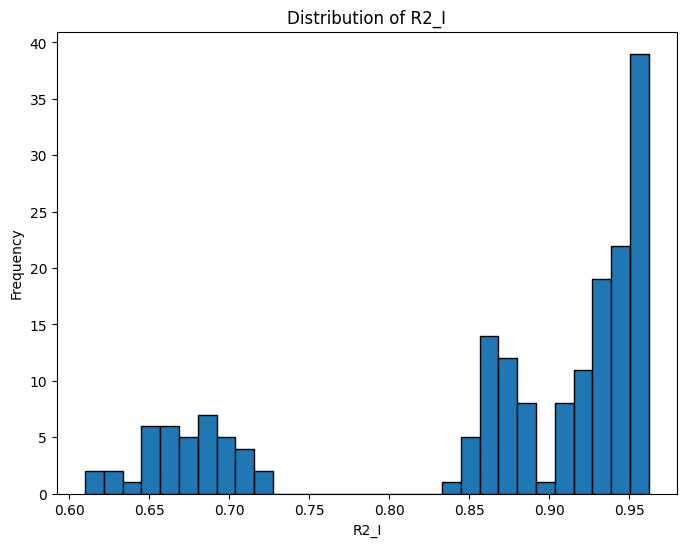

<Figure size 640x480 with 0 Axes>

In [6]:
import matplotlib.pyplot as plt
import os 

OUT_DIR="Analysis_plots"
os.makedirs(OUT_DIR,exist_ok=True)
#Histogram of R2_I
plt.figure(figsize=(8, 6))
plt.hist(master_df['R2_I'], bins=30, edgecolor='black')
plt.xlabel('R2_I')
plt.ylabel('Frequency')
plt.title('Distribution of R2_I')
plt.show()
plt.savefig(os.path.join(OUT_DIR,"R_2_I_distribution.png"), dpi=900, bbox_inches="tight")


### Log(R^2)

In [7]:
import matplotlib.pyplot as plt
import os

OUT_DIR="Analysis_plots"
os.makedirs(OUT_DIR,exist_ok=True)

#histogram of R2_I
plt.figure(figsize=(8, 6))
plt.hist(master_df['log_R2_I'], bins=30, edgecolor='black')
plt.xlabel('log(R2_I)')
plt.ylabel('Frequency')
plt.title('Distribution of log(R2_I)')
plt.show()
plt.savefig(os.path.join(OUT_DIR,"log(R_2_I)_distribution.png"), dpi=900, bbox_inches="tight")


KeyError: 'log_R2_I'

<Figure size 800x600 with 0 Axes>

### VIF

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import os
OUT_DIR = "Analysis_plots"
os.makedirs(OUT_DIR, exist_ok=True)

X_vif = X_mat.drop(columns=["Intercept"])

vif_df = pd.DataFrame({
    "predictor": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})

# Rule-of-thumb thresholds
def results(v):
    if v >= 10:  return "High"
    if v >= 5:   return "Moderate"
    return "low"

vif_df["Result"] = vif_df["VIF"].map(results)
vif_df = vif_df.sort_values("VIF", ascending=False).reset_index(drop=True)
print(vif_df.to_string(index=False))

with open(os.path.join(OUT_DIR,"VIF.txt"), "w", encoding="utf-8") as f:
    f.write(vif_df.to_string(index=False))


                                            predictor   VIF Result
                                         augmentation 3.750    low
                  train_strategy[T.MCMC]:augmentation 3.250    low
        train_strategy[T.UNIFORM_RANDOM]:augmentation 3.250    low
          C(train_strategy, Treatment("LHS"))[T.MCMC] 2.500    low
C(train_strategy, Treatment("LHS"))[T.UNIFORM_RANDOM] 2.500    low
           C(test_strategy, Treatment("LHS"))[T.MCMC] 1.625    low
 C(test_strategy, Treatment("LHS"))[T.UNIFORM_RANDOM] 1.625    low


### Relative MAE comaprison across sampling methods

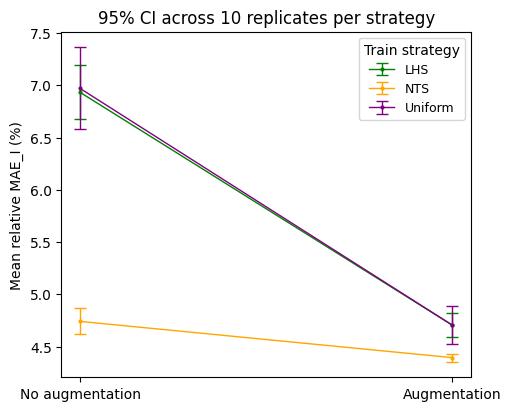

In [ ]:
import scipy.stats as stats

OUT_DIR="Analysis_plots"
os.makedirs(OUT_DIR,exist_ok=True)
#95% CI across replicatea per strategy
fig, ax = plt.subplots(figsize=(5, 4), constrained_layout=True)
palette = {"LHS": "green", "MCMC": "orange", "UNIFORM_RANDOM": "purple"}  # tab10 colors, 
label_map = {"LHS": "LHS", "MCMC": "NTS", "UNIFORM_RANDOM": "Uniform"}  # display names only -- keys must match train_strategy values

for train, color in palette.items():
    sub = master_df[master_df["train_strategy"] == train]
    assert not sub.empty, f"no rows found for train_strategy={train!r}"
    per_rep = sub.groupby(["augmentation", "replicate_id"])["relative_MAE_I"].mean()
    grouped = per_rep.groupby("augmentation")
    means = grouped.mean().reindex([0, 1])
    sems = grouped.sem().reindex([0, 1])
    n = grouped.size().reindex([0, 1])
    ci95 = sems * stats.t.ppf(0.975, df=n - 1)  # t-based 95% CI, n=10 replicates -> df=9 because my n is small
    ax.errorbar([0, 1], means.values, yerr=ci95.values, fmt="o-", color=color,
                label=label_map[train], lw=1, ms=2, capsize=4, elinewidth=1)

ax.set_xticks([0, 1])
ax.set_xticklabels(["No augmentation", "Augmentation"])
ax.set_ylabel("Mean relative MAE_I (%)")
ax.legend(title="Train strategy", fontsize=9)
ax.set_title("95% CI across 10 replicates per strategy")
fig.savefig(os.path.join(OUT_DIR,"fig_interaction_ci95.png"), dpi=900, bbox_inches="tight")

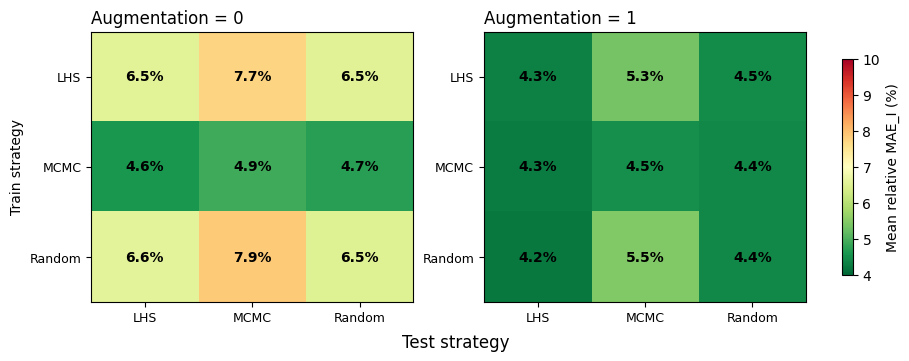

In [ ]:
import matplotlib.pyplot as plt
import os

OUT_DIR = "Analysis_plots"
os.makedirs(OUT_DIR, exist_ok=True)

strategies = ["LHS", "MCMC", "UNIFORM_RANDOM"]
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5), constrained_layout=True)

for ax, aug in zip(axes, [0, 1]):
    sub = master_df[master_df["augmentation"] == aug]
    matrix = sub.groupby(["train_strategy", "test_strategy"])["relative_MAE_I"].mean().unstack()
    matrix = matrix.loc[strategies, strategies]

    im = ax.imshow(matrix.values, cmap="RdYlGn_r", vmin=4, vmax=10, aspect="auto")
    ax.set_xticks(range(3)); ax.set_yticks(range(3))
    ax.set_xticklabels(["LHS", "MCMC", "Random"], fontsize=9)
    ax.set_yticklabels(["LHS", "MCMC", "Random"], fontsize=9)

    for i in range(3):
        for j in range(3):
            ax.text(j, i, f"{matrix.values[i, j]:.1f}%",
                    ha="center", va="center", fontsize=10, fontweight="bold")

    ax.set_title(f"Augmentation = {aug}", loc="left")

axes[0].set_ylabel("Train strategy")
fig.supxlabel("Test strategy")
fig.colorbar(im, ax=axes, label="Mean relative MAE_I (%)", shrink=0.8)
fig.savefig(os.path.join(OUT_DIR, "fig_heatmap1.png"),  dpi=900, bbox_inches="tight")


#### Hypothesis Testing

In [ ]:
from statsmodels.stats.anova import anova_lm
import numpy as np
import os

OUT_DIR = "Analysis_plots"
os.makedirs(OUT_DIR, exist_ok=True)

def scalar(value):
    """Return a Python float from statsmodels scalars or 1x1 arrays."""
    return float(np.asarray(value).squeeze())


lines = []

# Joint test 1: Does train strategy matter at all?
# H0: beta_train:LHS = beta_train:MCMC = 0
restrictions_train = (
    'C(train_strategy, Treatment("LHS"))[T.UNIFORM_RANDOM] = 0, '
    'C(train_strategy, Treatment("LHS"))[T.MCMC] = 0'
)
f_test_train = ols_model.f_test(restrictions_train)
lines.append("Joint test — train strategy effects :")
lines.append(f"  F = {scalar(f_test_train.fvalue):.3f}")
lines.append(f"  p = {f_test_train.pvalue:.4e}")

# Joint test 2: Does test strategy matter at all?
# H0: beta_test:LHS = beta_test:MCMC = 0
restrictions_test = (
    'C(test_strategy, Treatment("LHS"))[T.UNIFORM_RANDOM] = 0, '
    'C(test_strategy, Treatment("LHS"))[T.MCMC] = 0'
)
f_test_strategy = ols_model.f_test(restrictions_test)
lines.append("")
lines.append("Joint test — test strategy effects:")
lines.append(f"  F = {scalar(f_test_strategy.fvalue):.3f}")
lines.append(f"  p = {f_test_strategy.pvalue:.4e}")

# Joint test 3: Does augmentation matter?
# H0: beta_augmentation = 0
restrictions_aug = 'augmentation = 0'
f_test_aug = ols_model.f_test(restrictions_aug)
lines.append("")
lines.append("Joint test — augmentation effect:")
lines.append(f"  F = {scalar(f_test_aug.fvalue):.3f}")
lines.append(f"  p = {f_test_aug.pvalue:.4e}")

print(chr(10).join(lines))


with open(os.path.join(OUT_DIR, "joint_f_tests.txt"), "w", encoding="utf-8") as fh:
    fh.write(chr(10).join(lines))


Joint test — train strategy effects :
  F = 399.837
  p = 2.1316e-65

Joint test — test strategy effects:
  F = 119.354
  p = 3.1014e-33

Joint test — augmentation effect:
  F = 632.070
  p = 1.7191e-59


### Effect sizes

In [13]:
import numpy as np
import os

OUT_DIR = "Analysis_plots"
os.makedirs(OUT_DIR, exist_ok=True)

def cohen_d(g1, g2):
    n1, n2 = len(g1), len(g2)
    pooled_sd = np.sqrt(((n1-1)*g1.var(ddof=1) + (n2-1)*g2.var(ddof=1)) / (n1+n2-2))
    return (g1.mean() - g2.mean()) / pooled_sd

def d_label(d):
    ad = abs(d)
    if ad >= 0.8:  return "large"
    if ad >= 0.5:  return "medium"
    if ad >= 0.2:  return "small"
    return "negligible"


lines = []

# Cohen's d — Pairwise train_strategy comparisons

strategies = ["LHS", "MCMC", "UNIFORM_RANDOM"]
labels_map = {"LHS": "LHS", "MCMC": "MCMC", "UNIFORM_RANDOM": "Random"}

train_groups = {s: master_df.loc[master_df["train_strategy"] == s, "relative_MAE_I"].values
                for s in strategies}

lines.append("Cohen's d — Pairwise train_strategy comparisons")
lines.append(f"   {'Pair':<22}  {'Mean A (%)':>10}  {'Mean B (%)':>10}  {'Δ (pp)':>7}  {'d':>7}  {'Size'}")
for i, s1 in enumerate(strategies):
    for s2 in strategies[i+1:]:
        g1, g2 = train_groups[s1], train_groups[s2]
        d_val  = cohen_d(g1, g2)
        pair   = f"{labels_map[s1]} vs {labels_map[s2]}"
        lines.append(f"   {pair:<22}  {g1.mean():>10.3f}  {g2.mean():>10.3f}  "
              f"{g1.mean()-g2.mean():>+7.3f}  {d_val:>+7.3f}  {d_label(d_val)}")


# Cohen's d — Pairwise test_strategy comparisons

test_groups = {s: master_df.loc[master_df["test_strategy"] == s, "relative_MAE_I"].values
               for s in strategies}

lines.append("")
lines.append("Cohen's d — Pairwise test_strategy comparisons")
lines.append(f"   {'Pair':<22}  {'Mean A (%)':>10}  {'Mean B (%)':>10}  {'Change (pp)':>7}  {'d':>7}  {'Size'}")
for i, s1 in enumerate(strategies):
    for s2 in strategies[i+1:]:
        g1, g2 = test_groups[s1], test_groups[s2]
        d_val  = cohen_d(g1, g2)
        pair   = f"{labels_map[s1]} vs {labels_map[s2]}"
        lines.append(f"   {pair:<22}  {g1.mean():>10.3f}  {g2.mean():>10.3f}  "
              f"{g1.mean()-g2.mean():>+7.3f}  {d_val:>+7.3f}  {d_label(d_val)}")


# Cohen's d — Augmentation (0 vs 1)

aug0 = master_df.loc[master_df["augmentation"] == 0, "relative_MAE_I"].values
aug1 = master_df.loc[master_df["augmentation"] == 1, "relative_MAE_I"].values
d_aug = cohen_d(aug0, aug1)

lines.append("")
lines.append("Cohen's d — Augmentation (0 vs 1)")
lines.append(f"   {'Pair':<22}  {'Mean A (%)':>10}  {'Mean B (%)':>10}  {'Δ (pp)':>7}  {'d':>7}  {'Size'}")
lines.append(f"   {'aug=0 vs aug=1':<22}  {aug0.mean():>10.3f}  {aug1.mean():>10.3f}  "
      f"{aug0.mean()-aug1.mean():>+7.3f}  {d_aug:>+7.3f}  {d_label(d_aug)}")

print(chr(10).join(lines))

with open(os.path.join(OUT_DIR, "cohens_d_results.txt"), "w", encoding="utf-8") as fh:
    fh.write(chr(10).join(lines))


Cohen's d — Pairwise train_strategy comparisons
   Pair                    Mean A (%)  Mean B (%)   Δ (pp)        d  Size
   LHS vs MCMC                  5.819       4.567   +1.251   +1.371  large
   LHS vs Random                5.819       5.837   -0.019   -0.014  negligible
   MCMC vs Random               4.567       5.837   -1.270   -1.305  large

Cohen's d — Pairwise test_strategy comparisons
   Pair                    Mean A (%)  Mean B (%)  Change (pp)        d  Size
   LHS vs MCMC                  5.084       5.967   -0.883   -0.707  medium
   LHS vs Random                5.084       5.171   -0.087   -0.083  negligible
   MCMC vs Random               5.967       5.171   +0.796   +0.658  medium

Cohen's d — Augmentation (0 vs 1)
   Pair                    Mean A (%)  Mean B (%)   Δ (pp)        d  Size
   aug=0 vs aug=1               6.214       4.601   +1.614   +1.741  large


### Relative MAE comaprison across sampling methods

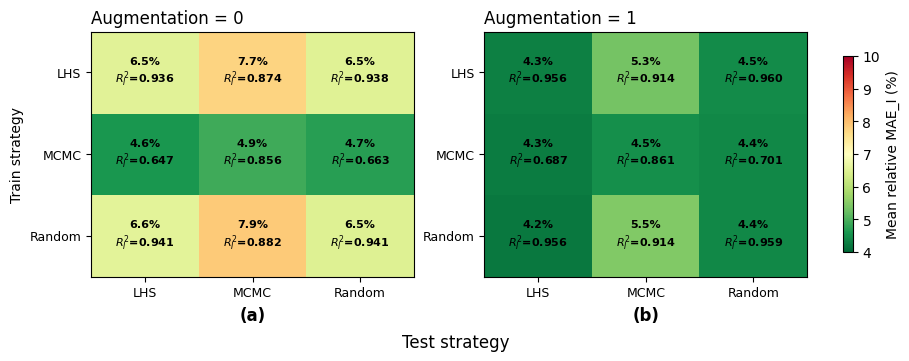

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

OUT_DIR="Analysis_plots"
os.makedirs(OUT_DIR,exist_ok=True)
strategies = ["LHS", "MCMC", "UNIFORM_RANDOM"]
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5), constrained_layout=True)

for idx, (ax, aug) in enumerate(zip(axes, [0, 1])):
    sub = master_df[master_df["augmentation"] == aug]
    matrix = sub.groupby(["train_strategy", "test_strategy"])["relative_MAE_I"].mean().unstack()
    matrix = matrix.loc[strategies, strategies]

    r2_matrix = sub.groupby(["train_strategy", "test_strategy"])["R2_I"].mean().unstack()
    r2_matrix = r2_matrix.loc[strategies, strategies]

    im = ax.imshow(matrix.values, cmap="RdYlGn_r", vmin=4, vmax=10, aspect="auto")
    ax.set_xticks(range(3)); ax.set_yticks(range(3))
    ax.set_xticklabels(["LHS", "MCMC", "Random"], fontsize=9)
    ax.set_yticklabels(["LHS", "MCMC", "Random"], fontsize=9)

    for i in range(3):
        for j in range(3):
            ax.text(j, i,
                    f"{matrix.values[i, j]:.1f}%\n$R^2_I$={r2_matrix.values[i, j]:.3f}",
                    ha="center", va="center", fontsize=8, fontweight="bold")

    ax.set_title(f"Augmentation = {aug}", loc="left")
    ax.text(0.5, -0.18, f"({chr(97 + idx)})", transform=ax.transAxes,
            fontsize=12, fontweight="bold", ha="center")

axes[0].set_ylabel("Train strategy")
fig.supxlabel("Test strategy")
fig.colorbar(im, ax=axes, label="Mean relative MAE_I (%)", shrink=0.8)
fig.savefig(os.path.join(OUT_DIR,"fig_heatmap2.png"), dpi=300, bbox_inches="tight")

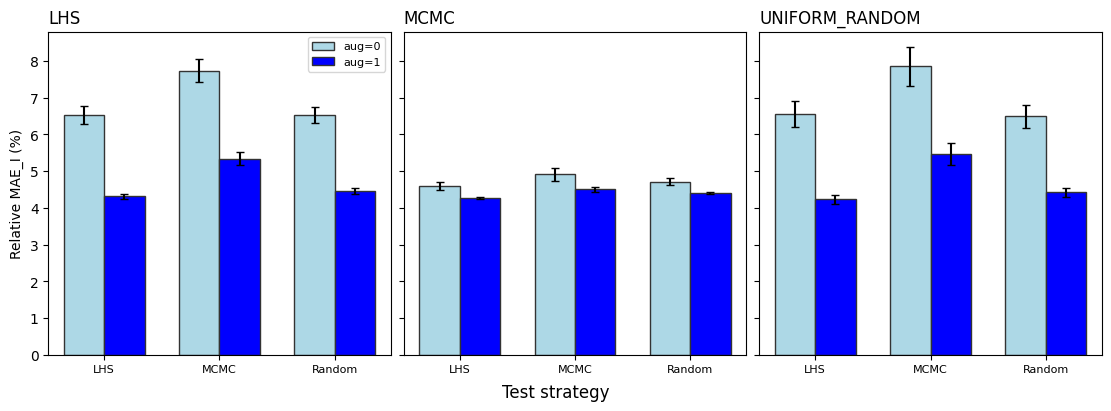

In [ ]:
from scipy import stats as scipy_stats
import os

# Histogram Comparison of relative error 
fig, axes = plt.subplots(1, 3, sharey=True, figsize=(11, 4), constrained_layout=True)
colors = {0: "lightblue", 1: "blue"}
test_order = ["LHS", "MCMC", "UNIFORM_RANDOM"]
x = np.arange(3)
w = 0.35

for ax, train in zip(axes, ["LHS", "MCMC", "UNIFORM_RANDOM"]):
    sub = master_df[master_df["train_strategy"] == train]
    for i, aug in enumerate([0, 1]):
        grouped = sub[sub["augmentation"] == aug].groupby("test_strategy")["relative_MAE_I"]
        means = grouped.mean().reindex(test_order)
        sems  = grouped.sem().reindex(test_order)
        ns    = grouped.size().reindex(test_order)
        ci95  = sems * scipy_stats.t.ppf(0.975, df=ns - 1)  # t-based 95% CI, n=10 replicates -> df=9
        ax.bar(x + i*w, means, w, yerr=ci95, capsize=3,
               color=colors[aug], label=f"aug={aug}", edgecolor="#333")
    ax.set_xticks(x + w/2)
    ax.set_xticklabels(["LHS", "MCMC", "Random"], fontsize=8)
    ax.set_title(train, loc="left")

axes[0].set_ylabel("Relative MAE_I (%)")
axes[0].legend(fontsize=8)
fig.supxlabel("Test strategy")
fig.savefig(os.path.join(OUT_DIR,"fig_bars.png"), dpi=300,bbox_inches="tight")


### Computational time 

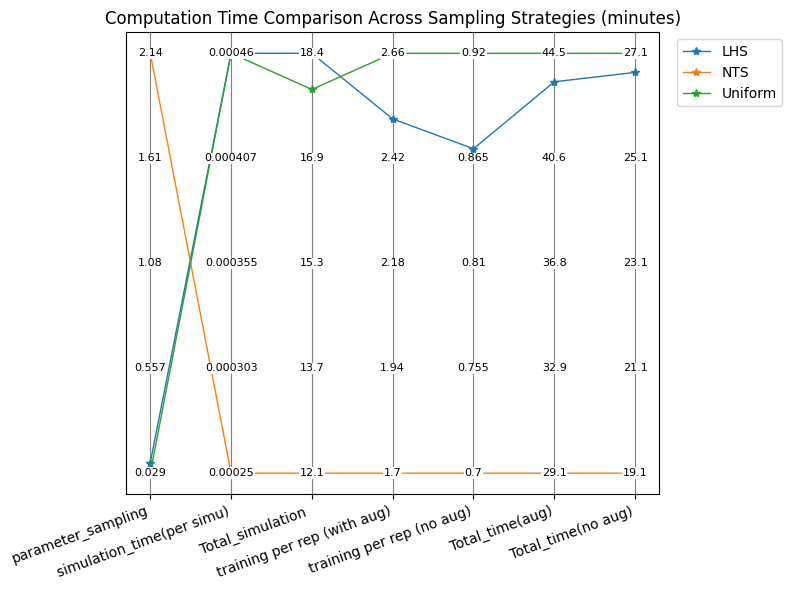

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

OUT_DIR="Analysis_plots"
os.makedirs(OUT_DIR,exist_ok=True)

data = pd.DataFrame({
    'parameter_sampling': [0.082, 2.14, 0.029],
    'simulation_time(per simu)': [0.00046, 0.00025, 0.00046],
    'Total_simulation ': [18.42, 12.14, 17.88],
    'training per rep (with aug)': [2.51, 1.70, 2.66],
    'training per rep (no aug)': [0.87, 0.70, 0.92],
    'Total_time(aug)': [43.42, 29.11, 44.46],
    'Total_time(no aug)': [26.7, 19.14, 27.06]
}, index=['LHS', 'NTS', 'Uniform'])

# Parallel coordinates plot. Each metric spans a very different range
# (e.g. 0.00025 to 44.46), so every axis is min-max normalized to [0, 1]
# purely for plotting position; the real values are printed as tick
# labels alongside each vertical axis instead of the shared 0-1 scale.
cols = data.columns
n_cols = len(cols)
x = np.arange(n_cols)

norm_data = (data - data.min()) / (data.max() - data.min())
norm_data = norm_data.fillna(0.5)  # guards against a constant column (max == min)

fig, ax = plt.subplots(figsize=(8, 6))

colors = plt.cm.tab10.colors
for i, (name, row) in enumerate(norm_data.iterrows()):
    ax.plot(x, row.values, marker='*', linewidth=1, color=colors[i], label=name, zorder=2)

n_ticks = 5
for j, col in enumerate(cols):
    ax.axvline(x[j], color='grey', linewidth=0.8, zorder=1)
    col_min, col_max = data[col].min(), data[col].max()
    for t in np.linspace(0, 1, n_ticks):
        real_val = col_min + t * (col_max - col_min)
        ax.text(x[j], t, f'{real_val:.3g}', ha='center', va='center', fontsize=8,
                zorder=2, bbox=dict(facecolor='white', edgecolor='none', pad=0.5))

ax.set_xticks(x)
ax.set_xticklabels(cols, rotation=20, ha='right')
ax.set_yticks([])
ax.set_ylim(-0.05, 1.05)
ax.set_xlim(-0.3, n_cols - 0.7)
ax.set_title("Computation Time Comparison Across Sampling Strategies (minutes)")
ax.legend( loc='upper left', bbox_to_anchor=(1.02, 1))

plt.savefig(os.path.join(OUT_DIR,"computation_time_comparison_parallel.png"),dpi=900,bbox_inches="tight")
plt.tight_layout()
plt.show()

#### Regression Analysis Assuptions- linearity and normality

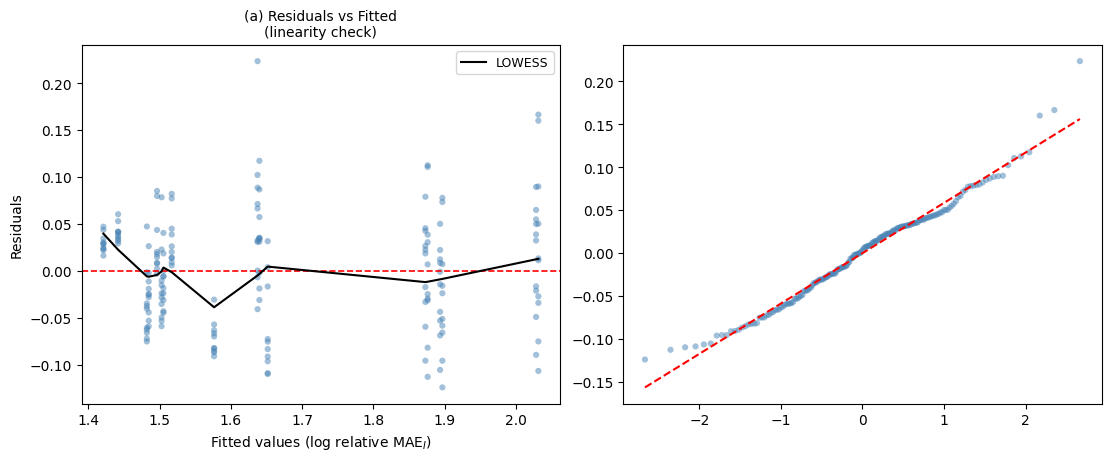

In [ ]:

import matplotlib.pyplot as plt
import numpy as np
from scipy import stats as scipy_stats
from statsmodels.graphics.gofplots import qqplot
import os

#Regression Analysis Assuptions- linearity and normality

fitted  = ols_model.fittedvalues
resid   = ols_model.resid
std_resid = resid / resid.std()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)

#  (a) Residuals vs Fitted — linearity check 
ax = axes[0]
ax.scatter(fitted, resid, alpha=0.5, s=20, color="steelblue", edgecolors="none")
ax.axhline(0, color="red", lw=1.2, ls="--")

# LOWESS smoother to reveal any systematic curvature
from statsmodels.nonparametric.smoothers_lowess import lowess
smooth = lowess(resid, fitted, frac=0.4)
ax.plot(smooth[:, 0], smooth[:, 1], color="black", lw=1.5, label="LOWESS")

ax.set_xlabel("Fitted values (log relative MAE$_I$)", fontsize=10)
ax.set_ylabel("Residuals", fontsize=10)
ax.set_title("(a) Residuals vs Fitted\n(linearity check)", fontsize=10)
ax.legend(fontsize=9)

# (b) Normal Q–Q plot — normality check 
ax = axes[1]
(osm, osr), (slope, intercept, r) = scipy_stats.probplot(resid, dist="norm")
ax.scatter(osm, osr, alpha=0.5, s=20, color="steelblue", edgecolors="none")
ax.plot(osm, slope * np.array(osm) + intercept, color="red", lw=1.5, ls="--", label="Normal ref.")

fig.savefig(os.path.join(OUT_DIR,"fig_diagnostics_linearity_normality.png"), dpi=900,bbox_inches="tight")
plt.show()



#### log tranformation for skewed relative MAE

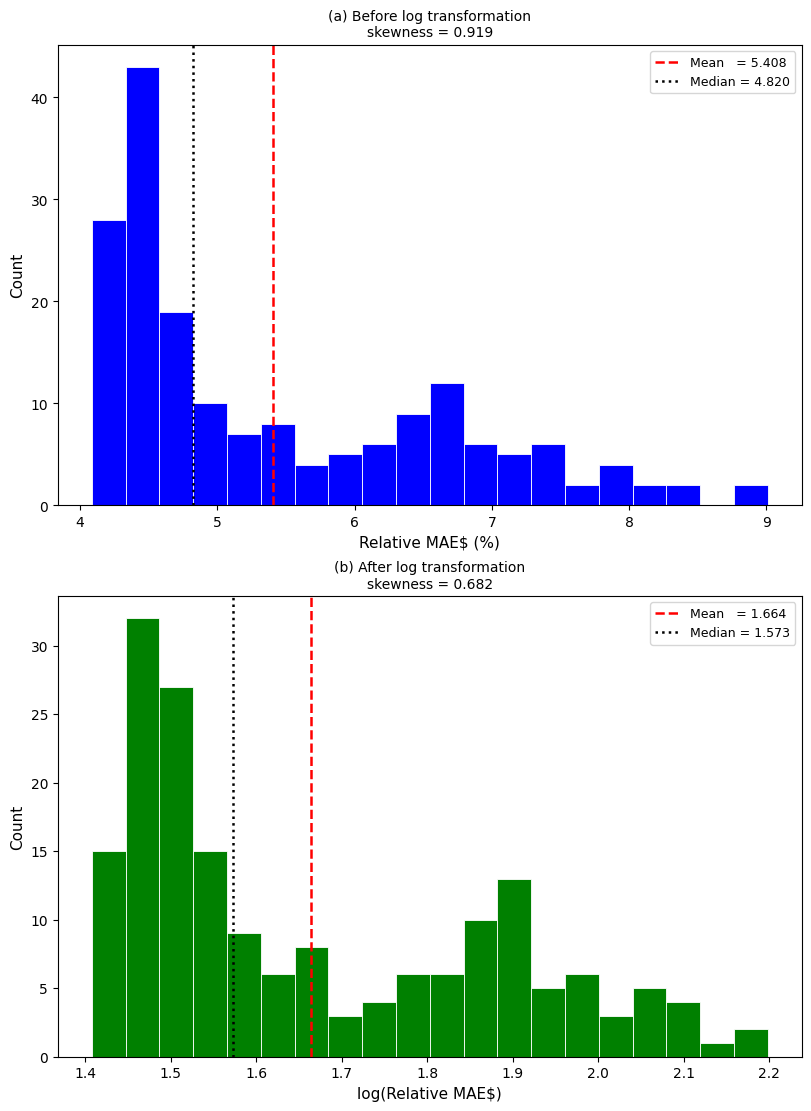

Raw   skewness=0.9189  mean=5.4076  median=4.8197  std=1.2285
Log   skewness=0.6816  mean=1.6643  median=1.5727  std=0.2126


In [ ]:
from scipy import stats as scipy_stats
import matplotlib.pyplot as plt

OUT_DIR="Analysis_plots"
os.makedirs(OUT_DIR,exist_ok=True)

#log tranformation for skewed relative MAE
raw = master_df["relative_MAE_I"]
log = master_df["log_relative_MAE_I"]

fig, axes = plt.subplots(2, 1, figsize=(8, 11), constrained_layout=True)

for ax, y, xlabel, title_label, colour in zip(
    axes,
    [raw, log],
    ["Relative MAE$ (%)", "log(Relative MAE$)"],
    ["(a) Before log transformation", "(b) After log transformation"],
    ["blue", "green"],
):
    skew   = scipy_stats.skew(y)
    mean   = y.mean()
    median = y.median()

    ax.hist(y, bins=20, color=colour, edgecolor="white", linewidth=0.6)
    ax.axvline(mean,   color="red",   lw=1.8, ls="--", label=f"Mean   = {mean:.3f}")
    ax.axvline(median, color="black", lw=1.8, ls=":",  label=f"Median = {median:.3f}")
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel("Count", fontsize=11)
    ax.set_title(f"{title_label}\nskewness = {skew:.3f}", fontsize=10)
    ax.legend(fontsize=9)

fig.savefig(os.path.join(OUT_DIR,"fig_histogram_distribution_comparison.png"), dpi=900,bbox_inches="tight")
plt.show()

for label, y in [("Raw", raw), ("Log", log)]:
    print(f"{label:4s}  skewness={scipy_stats.skew(y):.4f}  "
          f"mean={y.mean():.4f}  median={y.median():.4f}  std={y.std():.4f}")


# Cluster Adequacy & Independence Diagnostics

1. CLUSTER COUNT & SIZE
   Number of clusters (G)          : 18
   Observations per cluster (n_g)  : [10]
   Total observations (N)          : 180
2. INTRA-CLUSTER CORRELATION (ICC)
   ICC = 0.3080
3. MEAN RESIDUALS BY CLUSTER
                   condition_id      mean      std  n
                    MCMC_MCMC_1 -0.071190 0.018293 10
                    MCMC_MCMC_0 -0.061538 0.049905 10
           UNIFORM_RANDOM_LHS_1 -0.039982 0.038023 10
UNIFORM_RANDOM_UNIFORM_RANDOM_0 -0.027322 0.066297 10
                      LHS_LHS_1 -0.023762 0.025152 10
           LHS_UNIFORM_RANDOM_0 -0.018984 0.047453 10
UNIFORM_RANDOM_UNIFORM_RANDOM_1 -0.017097 0.041311 10
           LHS_UNIFORM_RANDOM_1 -0.011019 0.026800 10
           UNIFORM_RANDOM_LHS_0  0.002189 0.073941 10
                      LHS_LHS_0  0.003249 0.053415 10
                     LHS_MCMC_0  0.015735 0.056750 10
          UNIFORM_RANDOM_MCMC_0  0.025133 0.092431 10
                     MCMC_LHS_0  0.028055 0.031466 10
                 

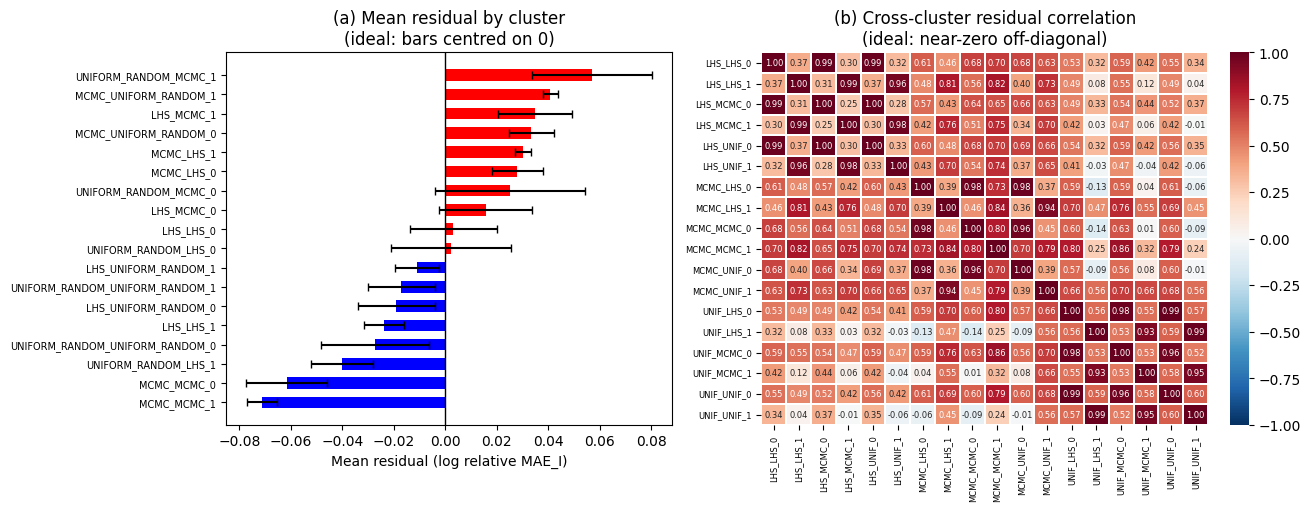

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats as scipy_stats
from statsmodels.stats.inter_rater import fleiss_kappa  # not used but keep imports clean
import os

OUT_DIR="Analysis_plots"
os.makedirs(OUT_DIR,exist_ok=True)




# Attach residuals to the dataframe 
master_df["resid"] = ols_model.resid.values

cluster_col = "condition_id"
G = master_df[cluster_col].nunique()
cluster_sizes = master_df.groupby(cluster_col).size()


print("1. CLUSTER COUNT & SIZE")

print(f"   Number of clusters (G)          : {G}")
print(f"   Observations per cluster (n_g)  : {cluster_sizes.unique().tolist()}")
print(f"   Total observations (N)          : {len(master_df)}")


#  1. Intra-cluster Correlation (ICC) 
print("2. INTRA-CLUSTER CORRELATION (ICC)")
# ICC = between-cluster variance / total variance (from one-way ANOVA decomposition)
grand_mean = master_df["resid"].mean()
cluster_means = master_df.groupby(cluster_col)["resid"].mean()
n_per = cluster_sizes.mean()

SS_between = sum(cluster_sizes[g] * (cluster_means[g] - grand_mean) ** 2
                 for g in cluster_means.index)
SS_within  = master_df.groupby(cluster_col)["resid"].apply(lambda x: ((x - x.mean()) ** 2).sum()).sum()

MS_between = SS_between / (G - 1)
MS_within  = SS_within  / (len(master_df) - G)

icc = (MS_between - MS_within) / (MS_between + (n_per - 1) * MS_within)
print(f"   ICC = {icc:.4f}")


#  2. Between-cluster residual pattern (heatmap) 

print("3. MEAN RESIDUALS BY CLUSTER")
clust_resid = (master_df.groupby(cluster_col)["resid"]
               .agg(mean="mean", std="std", n="count")
               .reset_index()
               .sort_values("mean"))
print(clust_resid.to_string(index=False))
print()

# 3. Cross-cluster residual correlation ─

print("4. CROSS-CLUSTER RESIDUAL CORRELATION")
# Pivot: rows = replicates, cols = clusters
resid_wide = master_df.pivot_table(
    index="replicate_id", columns=cluster_col, values="resid", aggfunc="mean"
)
corr_matrix = resid_wide.corr()



# 5. Figures 
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

# (a) Mean residual per cluster with 1 SD error bars
ax = axes[0]
colors_bar = ["red" if v > 0 else "blue" for v in clust_resid["mean"]]
ax.barh(clust_resid[cluster_col], clust_resid["mean"],
        xerr=clust_resid["std"] / np.sqrt(clust_resid["n"]),
        color=colors_bar, edgecolor="none", height=0.6, capsize=3)
ax.axvline(0, color="black", lw=1)
ax.set_xlabel("Mean residual (log relative MAE_I)")
ax.set_title("(a) Mean residual by cluster\n(ideal: bars centred on 0)")
ax.tick_params(axis="y", labelsize=7)

# (b) Cross-cluster correlation heatmap
ax = axes[1]
short_labels = [c.replace("UNIFORM_RANDOM", "UNIF") for c in corr_matrix.columns]
sns.heatmap(
    corr_matrix.values, ax=ax,
    xticklabels=short_labels, yticklabels=short_labels,
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    annot=True, fmt=".2f", annot_kws={"size": 6},
    linewidths=0.3,
)
ax.set_title("(b) Cross-cluster residual correlation\n(ideal: near-zero off-diagonal)")
ax.tick_params(axis="x", rotation=90, labelsize=6)
ax.tick_params(axis="y", rotation=0,  labelsize=6)

fig.savefig(os.path.join(OUT_DIR,"fig_cluster_diagnostics.png"), dpi=900, bbox_inches="tight")
plt.show()

In [ ]:
model_means = (
    master_df
    .groupby(["train_strategy", "replicate_id"])["relative_MAE_I"]
    .mean()
    .reset_index()
)

def cohen_d(g1, g2):
    n1, n2 = len(g1), len(g2)
    pooled_sd = np.sqrt(((n1-1)*g1.var(ddof=1) + (n2-1)*g2.var(ddof=1)) / (n1+n2-2))
    return (g1.mean() - g2.mean()) / pooled_sd

lhs  = model_means.loc[model_means["train_strategy"]=="LHS",           "relative_MAE_I"]
mcmc = model_means.loc[model_means["train_strategy"]=="MCMC",          "relative_MAE_I"]
rand = model_means.loc[model_means["train_strategy"]=="UNIFORM_RANDOM","relative_MAE_I"]

print(f"LHS  mean = {lhs.mean():.3f}%   (n={len(lhs)})")
print(f"MCMC mean = {mcmc.mean():.3f}%   (n={len(mcmc)})")
print(f"Rand mean = {rand.mean():.3f}%   (n={len(rand)})")
print()
print(f"LHS  vs MCMC  d = {cohen_d(lhs,  mcmc):.3f}")
print(f"LHS  vs Rand  d = {cohen_d(lhs,  rand):.3f}")
print(f"MCMC vs Rand  d = {cohen_d(mcmc, rand):.3f}")

LHS  mean = 5.819%   (n=10)
MCMC mean = 4.567%   (n=10)
Rand mean = 5.837%   (n=10)

LHS  vs MCMC  d = 7.295
LHS  vs Rand  d = -0.062
MCMC vs Rand  d = -4.763


# Distribution of Mean Relative MAE$_I$ by Sampling Strategy

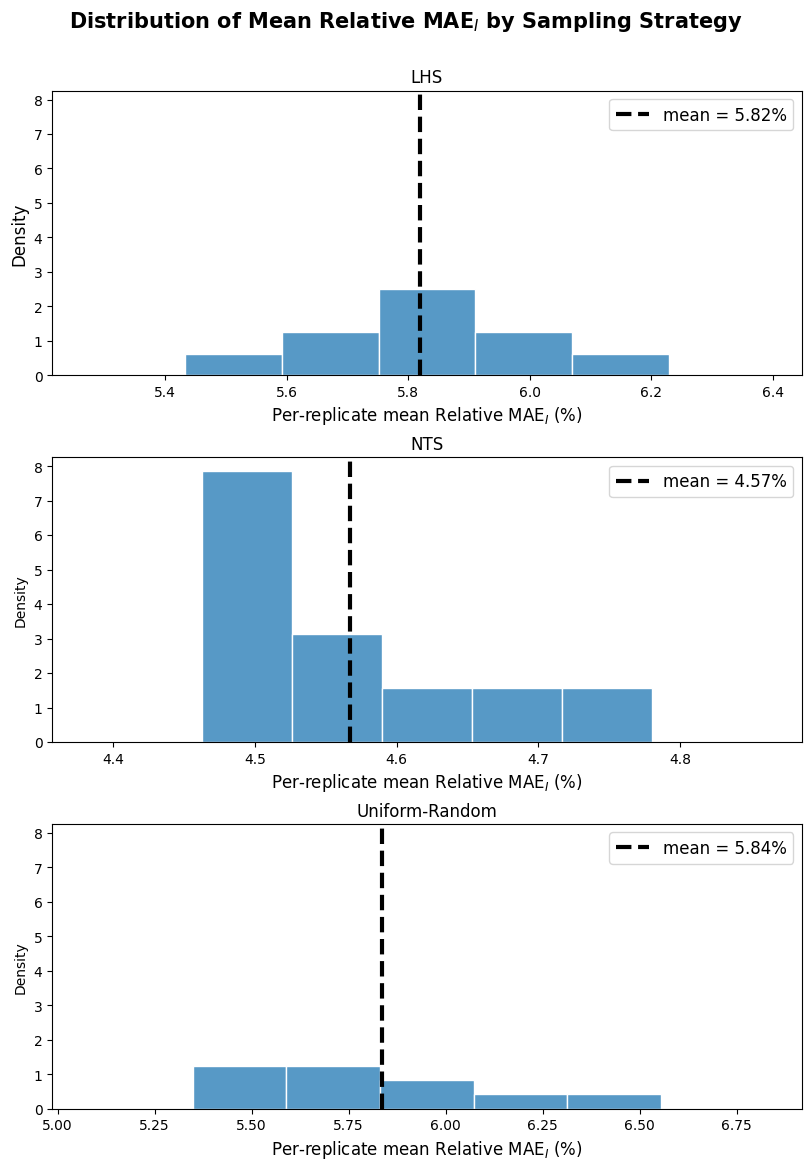

LHS             mean=5.819%  median=5.792%  std=0.218%  n=10
MCMC            mean=4.567%  median=4.524%  std=0.106%  n=10
UNIFORM_RANDOM  mean=5.837%  median=5.794%  std=0.362%  n=10


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import os

OUT_DIR="Analysis_plots"
os.makedirs(OUT_DIR,exist_ok=True)

strategy_order  = ["LHS", "MCMC", "UNIFORM_RANDOM"]
strategy_labels = {"LHS": "LHS", "MCMC": "NTS", "UNIFORM_RANDOM": "Uniform-Random"}
palette = {strategy_labels[s]: c for s, c in zip(strategy_order, ["tab:blue", "tab:blue", "tab:blue"])}

fig, axes = plt.subplots(3, 1, figsize=(8, 11), constrained_layout=True, sharex=False, sharey=True)

for ax, strategy in zip(axes, strategy_order):
    vals  = model_means.loc[model_means["train_strategy"] == strategy, "relative_MAE_I"]
    color = palette[strategy_labels[strategy]]

    sns.histplot(vals, stat="density", color=color, edgecolor="white", ax=ax)
    ax.axvline(vals.mean(), color="black", lw=3, ls="--", label=f"mean = {vals.mean():.2f}%")

    ax.set_title(strategy_labels[strategy], fontsize=12)

    ax.set_xlim(vals.min() - vals.std(), vals.max() + vals.std())
    ax.set_xlabel("Per-replicate mean Relative MAE$_I$ (%)", fontsize=12)
    ax.legend(fontsize=12)

axes[0].set_ylabel("Density", fontsize=12)
fig.suptitle("Distribution of Mean Relative MAE$_I$ by Sampling Strategy", fontsize=15, fontweight="bold", y=1.05)

fig.savefig(os.path.join(OUT_DIR,"fig_mean_relative_mae_by_strategy.png"), dpi=900, bbox_inches="tight")
plt.show()

for strategy in strategy_order:
    vals = model_means.loc[model_means["train_strategy"] == strategy, "relative_MAE_I"]
    print(f"{strategy:15s} mean={vals.mean():.3f}%  median={vals.median():.3f}%  std={vals.std():.3f}%  n={len(vals)}")


# Consistency of rMAE$I$ Across Replicates by Strategy

Robustness / consistency across replicates (lower CV = more consistent retrains)
                 mean    std   n  cv_pct
train_strategy                          
LHS             5.819  0.218  10   3.754
MCMC            4.567  0.106  10   2.311
UNIFORM_RANDOM  5.837  0.362  10   6.202


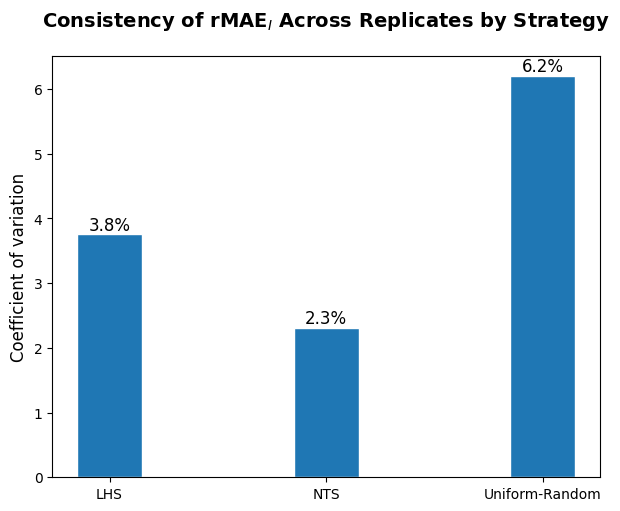

In [ ]:
import matplotlib.pyplot as plt
import os

OUT_DIR="Analysis_plots"
os.makedirs(OUT_DIR,exist_ok=True)

strategy_order  = ["LHS", "MCMC", "UNIFORM_RANDOM"]
strategy_labels = {"LHS": "LHS", "MCMC": "NTS", "UNIFORM_RANDOM": "Uniform-Random"}
palette = {strategy_labels[s]: c for s, c in zip(strategy_order, ["tab:blue", "tab:blue", "tab:blue"])}

variability = (
    model_means
    .groupby("train_strategy")["relative_MAE_I"]
    .agg(mean="mean", std="std", n="count")
    .reindex(strategy_order)
)
variability["cv_pct"] = variability["std"] / variability["mean"] * 100

print("Robustness / consistency across replicates (lower CV = more consistent retrains)")
print(variability.round(3))

fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)
bars = ax.bar(
    [strategy_labels[s] for s in strategy_order],
    variability["cv_pct"],
    width=0.3,
    color=[palette[strategy_labels[s]] for s in strategy_order],
    edgecolor="white",
)
for bar, cv in zip(bars, variability["cv_pct"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{cv:.1f}%",
            ha="center", va="bottom", fontsize=12)

ax.set_ylabel("Coefficient of variation", fontsize=12)
ax.set_title("Consistency of rMAE$_I$ Across Replicates by Strategy", fontsize=14, fontweight="bold",y=1.05)

fig.savefig(os.path.join(OUT_DIR,"fig_cv_by_strategy.png"), dpi=900, bbox_inches="tight")
plt.show()


### Generalization gap -OOD and ID

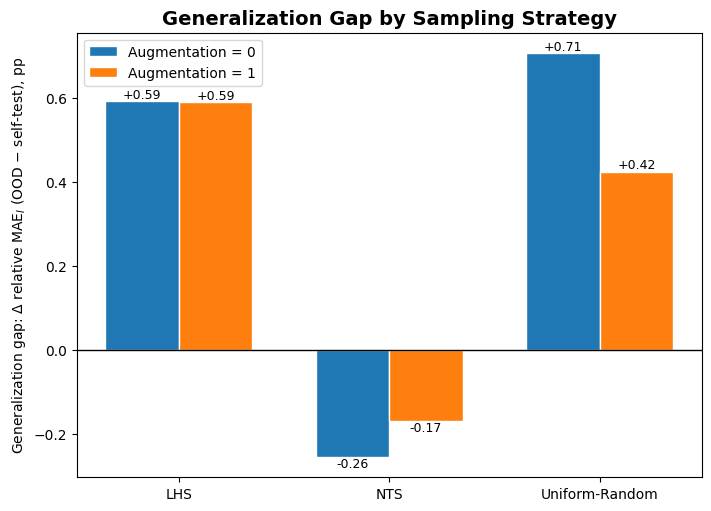

train_strategy  augmentation  relative_MAE_I_self  relative_MAE_I_ood   gap_pct
           LHS             0              6.53807            7.130110  0.592040
           LHS             1              4.31157            4.900760  0.589190
          MCMC             0              4.91067            4.655345 -0.255325
          MCMC             1              4.50650            4.337385 -0.169115
UNIFORM_RANDOM             0              6.49890            7.205650  0.706750
UNIFORM_RANDOM             1              4.42175            4.845675  0.423925


In [ ]:


import matplotlib.pyplot as plt
import numpy as np
import os

OUT_DIR = "Analysis_plots"
os.makedirs(OUT_DIR, exist_ok=True)

strategy_order  = ["LHS", "MCMC", "UNIFORM_RANDOM"]
strategy_labels = {"LHS": "LHS", "MCMC": "NTS", "UNIFORM_RANDOM": "Uniform-Random"}

self_mask = master_df["train_strategy"] == master_df["test_strategy"]
self_stats = (master_df[self_mask]
              .groupby(["train_strategy", "augmentation"])["relative_MAE_I"]
              .mean().reset_index()
              .rename(columns={"relative_MAE_I": "relative_MAE_I_self"}))
ood_stats = (master_df[~self_mask]
             .groupby(["train_strategy", "augmentation"])["relative_MAE_I"]
             .mean().reset_index()
             .rename(columns={"relative_MAE_I": "relative_MAE_I_ood"}))
stability = self_stats.merge(ood_stats, on=["train_strategy", "augmentation"])



gap = stability.copy()
gap["gap_pct"] = gap["relative_MAE_I_ood"] - gap["relative_MAE_I_self"]

fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)

x = np.arange(len(strategy_order))
width = 0.35

for i, aug in enumerate([0, 1]):
    vals = [gap.loc[(gap["train_strategy"] == s) & (gap["augmentation"] == aug), "gap_pct"].values[0]
            for s in strategy_order]
    xpos = x + (i - 0.5) * width
    ax.bar(xpos, vals, width, label=f"Augmentation = {aug}", edgecolor="white")
    for xi, v in zip(xpos, vals):
        ax.text(xi, v, f"{v:+.2f}", ha="center",
                va="bottom" if v >= 0 else "top", fontsize=9)

ax.axhline(0, color="black", lw=1)
ax.set_xticks(x)
ax.set_xticklabels([strategy_labels[s] for s in strategy_order])
ax.set_ylabel(r"Generalization gap: $\Delta$ relative MAE$_I$ (OOD $-$ self-test), pp")
ax.set_title("Generalization Gap by Sampling Strategy", fontsize=14, fontweight="bold")
ax.legend()

fig.savefig(os.path.join(OUT_DIR, "fig_generalization_delta.png"), dpi=900)
plt.show()

print(gap[["train_strategy", "augmentation", "relative_MAE_I_self",
           "relative_MAE_I_ood", "gap_pct"]].to_string(index=False))


### Ranking: raw means with 95% CI

Rank each emulator by its
raw (unadjusted) sample mean, pooled across the 3 test strategies, with a plain
t-based 95% CI on the mean .
Both `relative_MAE_I` and `R2_I` are reported so the two metrics can be compared
directly.

In [ ]:

import os

OUT_DIR = "Analysis_plots"
os.makedirs(OUT_DIR, exist_ok=True)

# OVERAL PREDICTIVE ACCURACY AND EMULATOR RANKING

def mean_ci(x, conf=0.95):
    x = x.dropna()
    n = len(x)
    m = x.mean()
    se = x.std(ddof=1) / np.sqrt(n)
    tcrit = scipy_stats.t.ppf(1 - (1 - conf) / 2, n - 1)
    return m, m - tcrit * se, m + tcrit * se, n

simple_rows = []
for (train, aug), g in master_df.groupby(["train_strategy", "augmentation"]):
    mae_mean, mae_lo, mae_hi, n = mean_ci(g["relative_MAE_I"])
    r2_mean, r2_lo, r2_hi, _ = mean_ci(g["R2_I"])
    simple_rows.append({
        "train_strategy": train, "augmentation": aug, "n": n,
        "mean_rel_MAE_I_%": mae_mean, "MAE_CI_lo": mae_lo, "MAE_CI_hi": mae_hi,
        "mean_R2_I": r2_mean, "R2_CI_lo": r2_lo, "R2_CI_hi": r2_hi,
    })

simple_table = pd.DataFrame(simple_rows)
simple_table["rank_MAE_I"] = simple_table["mean_rel_MAE_I_%"].rank(ascending=True).astype(int)
simple_table["rank_R2_I"] = simple_table["mean_R2_I"].rank(ascending=False).astype(int)
simple_table = simple_table.sort_values("rank_MAE_I").reset_index(drop=True)

lines = []
lines.append("Simple ranking: raw per-emulator mean\n"
      "+/- 95% CI, pooled across the 3 test strategies (no model adjustment).\n")
lines.append(simple_table[["train_strategy", "augmentation", "n",
                     "mean_rel_MAE_I_%", "MAE_CI_lo", "MAE_CI_hi", "rank_MAE_I",
                     "mean_R2_I", "R2_CI_lo", "R2_CI_hi", "rank_R2_I"]].round(3).to_string(index=False))

n_rank_agree = (simple_table["rank_MAE_I"] == simple_table["rank_R2_I"]).sum()
lines.append(f"\n{n_rank_agree} / {len(simple_table)} emulators get the same rank from relative_MAE_I and R2_I.")

print("\n".join(lines))

with open(os.path.join(OUT_DIR, "overall_predictive_accuracy.txt"), "w", encoding="utf-8") as f:
    f.write("\n".join(lines))


Simple ranking: raw per-emulator mean
+/- 95% CI, pooled across the 3 test strategies (no model adjustment).

train_strategy  augmentation  n  mean_rel_MAE_I_%  MAE_CI_lo  MAE_CI_hi  rank_MAE_I  mean_R2_I  R2_CI_lo  R2_CI_hi  rank_R2_I
          MCMC             1 30             4.394      4.351      4.436           1      0.750     0.719     0.780          5
           LHS             1 30             4.704      4.521      4.888           2      0.943     0.935     0.951          1
UNIFORM_RANDOM             1 30             4.704      4.476      4.933           3      0.943     0.935     0.951          2
          MCMC             0 30             4.740      4.658      4.823           4      0.722     0.686     0.759          6
           LHS             0 30             6.933      6.680      7.185           5      0.916     0.905     0.927          4
UNIFORM_RANDOM             0 30             6.970      6.657      7.283           6      0.921     0.911     0.932          3

0 / 6 e

#### Stochastic SIR dynamics near the epidemic threshold 

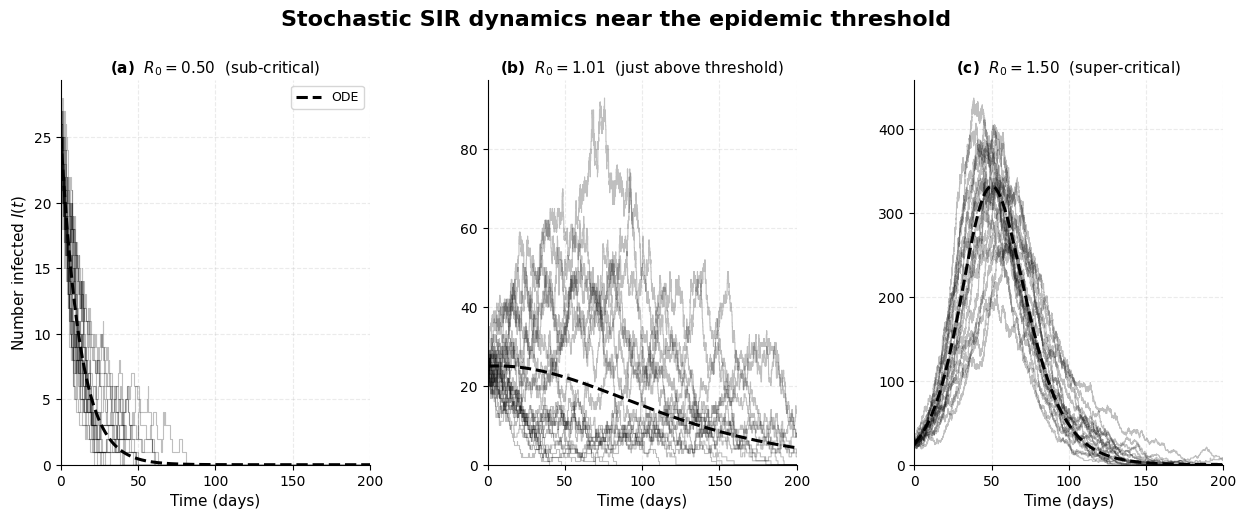

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.integrate import solve_ivp
import os 

OUT_DIR = "Analysis_plots"
os.makedirs(OUT_DIR, exist_ok=True)


np.random.seed(2024)

N = 5000
GAMMA  = 0.16
I0 = 25
S0 = N - I0
T_END  = 200
N_REAL = 20        # realisations per panel

SCENARIOS = [
    (0.50 * GAMMA, r'$R_0 = 0.50$  (sub-critical)',  'black'),
    (1.01 * GAMMA, r'$R_0 = 1.01$  (just above threshold)', 'black'),
    (1.50 * GAMMA, r'$R_0 = 1.50$  (super-critical)', 'black'),
]


# Gillespie SSA 
def gillespie_sir(beta, gamma, N, S0, I0, t_end, seed=None):
    rng = np.random.default_rng(seed)
    S, I, R = S0, I0, N - S0 - I0
    t = 0.0
    ts, Is = [t], [I]
    while t < t_end and I > 0:
        lam_inf = beta * S * I / N
        lam_rec = gamma * I
        lam_tot = lam_inf + lam_rec
        if lam_tot == 0:
            break
        t += rng.exponential(1.0 / lam_tot)
        if t > t_end:
            break
        if rng.random() < lam_inf / lam_tot:
            S -= 1; I += 1
        else:
            I -= 1; R += 1
        ts.append(t); Is.append(I)
    # pad to t_end at final value
    if ts[-1] < t_end:
        ts.append(t_end); Is.append(Is[-1])
    return np.array(ts), np.array(Is, dtype=float)


# ODE solution 
def ode_I(beta, gamma, N, S0, I0, t_end):
    def rhs(t, y):
        S, I, _ = y
        return [-beta*S*I/N, beta*S*I/N - gamma*I, gamma*I]
    t_eval = np.linspace(0, t_end, 800)
    sol = solve_ivp(rhs, [0, t_end], [S0, I0, 0],
                    t_eval=t_eval, method='RK45', rtol=1e-9)
    return sol.t, sol.y[1]


# Figure 
fig = plt.figure(figsize=(15, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.38)

for col, (beta, title, colour) in enumerate(SCENARIOS):
    ax  = fig.add_subplot(gs[col])
    R0  = beta / GAMMA

    # Stochastic realisations
    n_extinct = 0
    for seed in range(N_REAL):
        ts, Is = gillespie_sir(beta, GAMMA, N, S0, I0, T_END, seed=seed)
        peak   = Is.max()
        extinct = peak < 5          # trivial epidemic (fewer than 5 individuals infected)
        n_extinct += int(extinct)
        ax.step(ts, Is, '-',
                color=colour, lw=0.8,
                alpha=0.25 if not extinct else 0.15,
                where='post')

    # ODE
    t_ode, I_ode = ode_I(beta, GAMMA, N, S0, I0, T_END)
    ax.plot(t_ode, I_ode, '--', color='black', lw=2.2,
            label='ODE', zorder=8)

    # Annotations
    ax.set_title(
        rf'$\mathbf{{({chr(97+col)})}}$  {title}',
        fontsize=11, pad=5
    )
   
    ax.set_xlabel('Time (days)', fontsize=11)
    if col == 0:
        ax.set_ylabel(r'Number infected $I(t)$', fontsize=11)
    ax.set_xlim(0, T_END)
    ax.set_ylim(bottom=0)
    ax.grid(True, alpha=0.25, linestyle='--')
    ax.spines[['top', 'right']].set_visible(False)
    if col == 0:
        ax.legend(fontsize=9)

fig.suptitle(
    rf'Stochastic SIR dynamics near the epidemic threshold  ',
    fontsize=16, fontweight='bold', y=1.02)

plt.savefig(os.path.join(OUT_DIR,"fig_stochastic_sir_threshold.png"), dpi=900, bbox_inches='tight')
plt.show()
plt.close()



#### Sampling Methods

Discrepancy (Random): 0.0008
Discrepancy (LHS): 0.0001
Discrepancy (Sobol): 0.0000


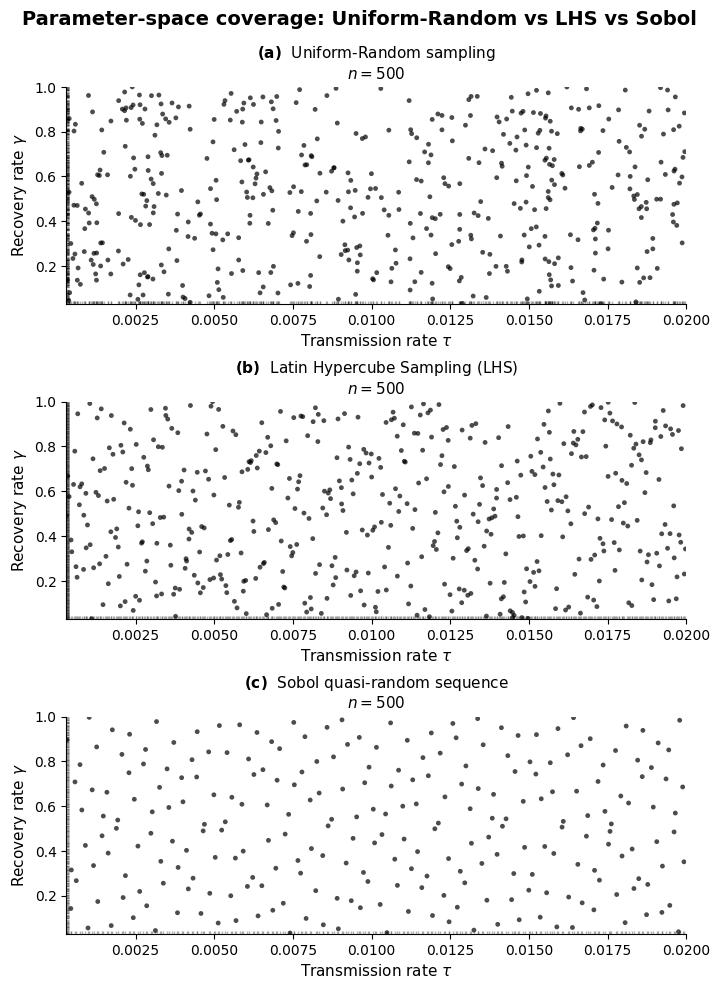

In [ ]:


import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import qmc

OUT_DIR = "Analysis_plots"
os.makedirs(OUT_DIR, exist_ok=True)

np.random.seed(42)

N_SAMPLES = 500

# Parameter bounds  [tau, gamma]
TAU_LO, TAU_HI   = 0.0003, 0.02
GAMMA_LO, GAMMA_HI = 0.03,   1.0

def scale(samples):
    """Scale unit-hypercube samples to [tau, gamma] bounds."""
    tau   = TAU_LO   + samples[:, 0] * (TAU_HI   - TAU_LO)
    gamma = GAMMA_LO + samples[:, 1] * (GAMMA_HI - GAMMA_LO)
    return tau, gamma


# 1. Random uniform sampling
rng = np.random.default_rng(42)
rand_raw = rng.uniform(size=(N_SAMPLES, 2))
tau_rand, gamma_rand = scale(rand_raw)

#  2. Latin Hypercube Sampling 
sampler_lhs = qmc.LatinHypercube(d=2, seed=42)
lhs_raw = sampler_lhs.random(N_SAMPLES)
tau_lhs, gamma_lhs = scale(lhs_raw)

# 3. Sobol sequence 
# n must be a power of 2 for proper Sobol; use 256 and take first 200
sampler_sobol = qmc.Sobol(d=2, scramble=True, seed=42)
sobol_raw = sampler_sobol.random(256)[:N_SAMPLES]
tau_sobol, gamma_sobol = scale(sobol_raw)


# Discrepancy (lower = more uniform coverage)
disc_rand  = qmc.discrepancy(rand_raw)
disc_lhs   = qmc.discrepancy(lhs_raw)
disc_sobol = qmc.discrepancy(sobol_raw)
for method_name, disc_value in [('Random', disc_rand), ('LHS', disc_lhs), ('Sobol', disc_sobol)]:
    print(f"Discrepancy ({method_name}): {disc_value:.4f}")


# Figure 

fig = plt.figure(figsize=(8, 11))
gs  = gridspec.GridSpec(3, 1, figure=fig, hspace=0.45)

configs = [
    (tau_rand,  gamma_rand,  'black', disc_rand,  'Random uniform',
     r'$\mathbf{(a)}$  Uniform-Random sampling'),
    (tau_lhs,   gamma_lhs,   'black', disc_lhs,   'LHS',
     r'$\mathbf{(b)}$  Latin Hypercube Sampling (LHS)'),
    (tau_sobol, gamma_sobol, 'black', disc_sobol, 'Sobol',
     r'$\mathbf{(c)}$  Sobol quasi-random sequence'),
]

for row, (tau, gamma, colour, disc, label, title) in enumerate(configs):
    ax = fig.add_subplot(gs[row])

    ax.scatter(tau, gamma, c=colour, s=12, alpha=0.70, edgecolors='none')

    ax.set_title(title + f'\n$n={N_SAMPLES}$', fontsize=11)
    ax.set_xlabel(r'Transmission rate $\tau$', fontsize=11)
    ax.set_ylabel(r'Recovery rate $\gamma$', fontsize=11)
    ax.set_xlim(TAU_LO, TAU_HI)
    ax.set_ylim(GAMMA_LO, GAMMA_HI)
    ax.spines[['top','right']].set_visible(False)
   

    # Marginal rug plots
    ax.plot(tau,  [GAMMA_LO]*len(tau),  '|',
            color=colour, ms=4, alpha=0.3)
    ax.plot([TAU_LO]*len(gamma), gamma, '_',
            color=colour, ms=4, alpha=0.3)

fig.suptitle(r'Parameter-space coverage: Uniform-Random vs LHS vs Sobol  ',
    fontsize=14, fontweight='bold', y=0.95)

plt.savefig(os.path.join(OUT_DIR,"fig_sampling_coverage.png"), dpi=900, bbox_inches='tight')
plt.show()
plt.close()

#### Homogeneous Mixing vs Network-Structured SIR

BA: N=5000, m=10, ratio=43.49
Homogeneous: tau=0.4000  R0=2.50
Network:     tau=0.0092   R0_net=2.50

Homogeneous (20 realisations) ...
BA network (20 realisations) ...


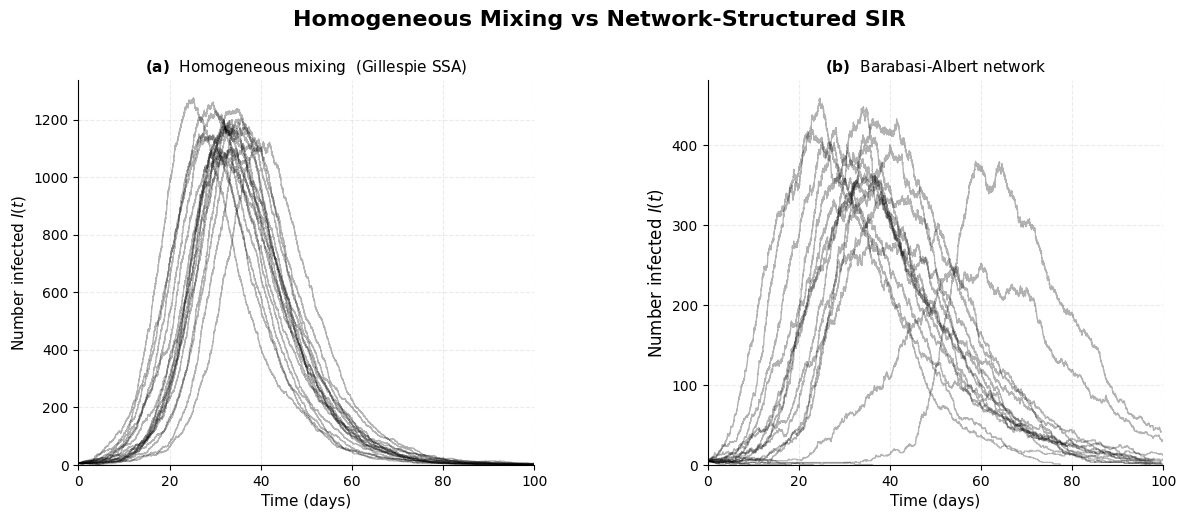

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import networkx as nx
import EoN

OUT_DIR="Analysis_plots"
os.makedirs(OUT_DIR,exist_ok=True)

np.random.seed(7)

N_NET  = 5000
M_BA   = 10
GAMMA  = 0.16
N_REAL = 20
T_END  = 100
I0 = 5
R0_TARGET = 2.5

# Build fixed BA network
G  = nx.barabasi_albert_graph(N_NET, M_BA, seed=42)
degrees = np.array([d for _, d in G.degree()])
mean_k  = degrees.mean()
mean_k2 = (degrees**2).mean()
ratio   = (mean_k2-mean_k)/ mean_k

# tau for EACH model to achieve R0 = 2.5
TAU_HOMO = R0_TARGET * GAMMA               # homogeneous mixing
TAU_NET  = R0_TARGET * GAMMA / ratio       # network (smaller tau)

print(f"BA: N={N_NET}, m={M_BA}, ratio={ratio:.2f}")
print(f"Homogeneous: tau={TAU_HOMO:.4f}  R0={TAU_HOMO/GAMMA:.2f}")
print(f"Network:     tau={TAU_NET:.4f}   R0_net={TAU_NET/GAMMA*ratio:.2f}")


def gillespie_homo(N, tau, gamma, I0, t_end, seed=None):
    rng = np.random.default_rng(seed)
    S, I = N - I0, I0
    t, ts, Is = 0.0, [0.0], [I0]
    while t < t_end and I > 0:
        lam = tau * S * I / N + gamma * I
        if lam == 0: break
        t += rng.exponential(1.0 / lam)
        if t > t_end: break
        if rng.random() < (tau * S * I / N) / lam:
            S -= 1; I += 1
        else:
            I -= 1
        ts.append(t); Is.append(I)
    ts.append(t_end); Is.append(Is[-1])
    return np.array(ts), np.array(Is, dtype=float)


def network_sir_eon(G, tau, gamma, I0_count, t_end, seed=None):
    if seed is not None:
        np.random.seed(seed)
    init = np.random.choice(list(G.nodes()), I0_count, replace=False)
    t, S, I, R = EoN.fast_SIR(G, tau, gamma,
                                initial_infecteds=init,
                                tmax=t_end, return_full_data=False)
    return t, I


fig = plt.figure(figsize=(14, 5.0))
gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.38)

# Panel (a) -- Homogeneous mixing
ax1 = fig.add_subplot(gs[0])
print(f"\nHomogeneous ({N_REAL} realisations) ...")
for seed in range(N_REAL):
    ts, Is = gillespie_homo(N_NET, TAU_HOMO, GAMMA, I0, T_END, seed)
    ax1.step(ts, Is, '-', color='black', lw=0.9, alpha=0.30,
             where='post')
ax1.set_title(
    r'$\mathbf{(a)}$  Homogeneous mixing  (Gillespie SSA)',
    fontsize=11)
ax1.set_xlabel('Time (days)', fontsize=11)
ax1.set_ylabel(r'Number infected $I(t)$', fontsize=11)
ax1.set_xlim(0, T_END); ax1.set_ylim(bottom=0)
ax1.grid(True, alpha=0.25, linestyle='--')
ax1.spines[['top','right']].set_visible(False)

# Panel (b) -- BA network
ax2 = fig.add_subplot(gs[1])
print(f"BA network ({N_REAL} realisations) ...")
for seed in range(N_REAL):
    ts, Is = network_sir_eon(G, TAU_NET, GAMMA, I0, T_END, seed)
    ax2.step(ts, Is, '-', color='black', lw=0.9, alpha=0.30,
             where='post')
ax2.set_title(
    r'$\mathbf{(b)}$  Barabasi-Albert network',
    fontsize=11)
ax2.set_xlabel('Time (days)', fontsize=11)
ax2.set_ylabel(r'Number infected $I(t)$', fontsize=12)
ax2.set_xlim(0, T_END); ax2.set_ylim(bottom=0)
ax2.grid(True, alpha=0.25, linestyle='--')
ax2.spines[['top','right']].set_visible(False)


fig.suptitle(
    r'Homogeneous Mixing vs Network-Structured SIR ',
    fontsize=16, fontweight='bold', y=1.02)

plt.savefig(os.path.join(OUT_DIR,"fig_network_vs_homogeneous.png"), dpi=900, bbox_inches='tight')
plt.show()



### Distribution of Epidemic Peak $I_{max}$ by Test Strategy'

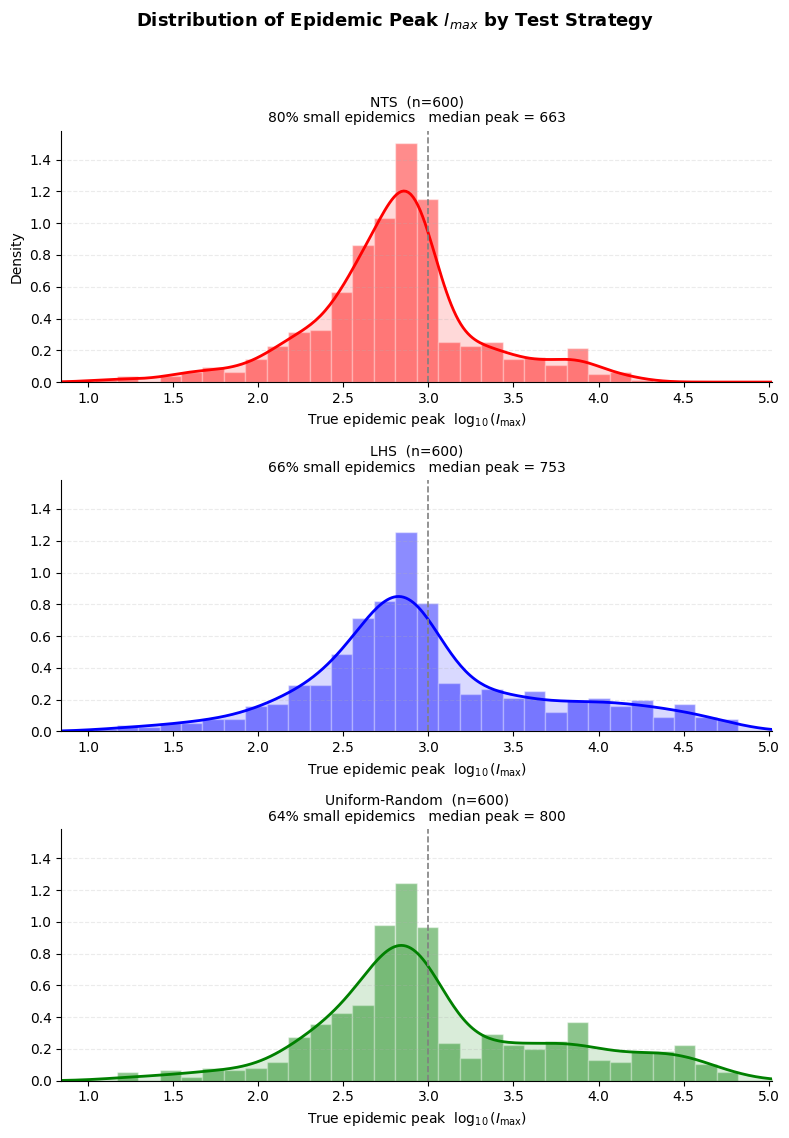

<Figure size 640x480 with 0 Axes>

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

COLOURS = {
    'MCMC'           : 'red',
    'LHS'            : 'blue',
    'UNIFORM_RANDOM' : 'green',
}
LABELS = {
    'MCMC'           : 'NTS',
    'LHS'            : 'LHS',
    'UNIFORM_RANDOM' : 'Uniform-Random',
}


#  LOAD DATA


def load_master(df):
    df = df.copy()

    # Normalise strategy name spellings
    df['test_strategy']  = df['test_strategy'].str.upper().str.strip()
    df['train_strategy'] = df['train_strategy'].str.upper().str.strip()

    # Keep the three expected strategy labels
    valid = ['MCMC', 'LHS', 'UNIFORM_RANDOM']
    df = df[df['test_strategy'].isin(valid)].copy()

    print(f"Loaded {len(df)} rows x {len(df.columns)} columns")
    print(f"Strategies: {df['test_strategy'].unique().tolist()}")
    print(f"\nColumn summary:")
    for col in ['relative_MAE_I','MAE_I','R2_I','mean_peak_I']:
        if col in df.columns:
            print(f"  {col:20s}: "
                  f"mean={df[col].mean():.4f}  "
                  f"std={df[col].std():.4f}  "
                  f"range=[{df[col].min():.4f}, {df[col].max():.4f}]")
        else:
            print(f"  {col:20s}: MISSING - check column name")

    return df


def load_peak_samples():
    """Per-sample true peak_I, one row per test epidemic (n=600/strategy)."""
    files = sorted(DATA_DIR.glob("per_sample_peak_*.csv"))
    peak_df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
    peak_df['test_strategy']  = peak_df['test_strategy'].str.upper().str.strip()
    peak_df['train_strategy'] = peak_df['train_strategy'].str.upper().str.strip()

    # peak_I depends only on test_strategy (same test set reused across
    # train strategies) -- keep one clean copy per strategy via the self-test file
    peak_df = peak_df[peak_df['train_strategy'] == peak_df['test_strategy']]
    return peak_df[['test_strategy', 'peak_I']].reset_index(drop=True)


peak_df = load_peak_samples()

strategies = ['MCMC', 'LHS', 'UNIFORM_RANDOM']

NEAR_EXTINCTION = 1000
log_thresh = np.log10(NEAR_EXTINCTION)

# Shared x-axis range and bin edges across all three strategies, so panels
# are directly comparable instead of each being autoscaled to its own data.
all_vals = np.log10(peak_df['peak_I'].clip(lower=1))
x_min, x_max = all_vals.min() - 0.2, all_vals.max() + 0.2
bin_edges = np.linspace(all_vals.min(), all_vals.max(), 31)
x_grid = np.linspace(x_min, x_max, 300)

fig, axes = plt.subplots(3, 1, figsize=(8, 11), sharex=True, sharey=True)

for ax, strat in zip(axes, strategies):
    vals = np.log10(
        peak_df.loc[peak_df['test_strategy'] == strat, 'peak_I'].clip(lower=1)
    )

    ax.hist(vals, bins=bin_edges, density=True, color=COLOURS[strat],
            alpha=0.45, edgecolor='white')

    density = stats.gaussian_kde(vals)(x_grid)
    ax.plot(x_grid, density, color=COLOURS[strat], lw=2)
    ax.fill_between(x_grid, density, color=COLOURS[strat], alpha=0.15)

    ax.axvline(log_thresh, color='grey', linestyle='--', lw=1.2)
    ax.set_xlim(x_min, x_max)
    ax.tick_params(axis='x', labelbottom=True)  # sharex hides these by default on non-bottom rows

    pct_small = (vals < log_thresh).mean() * 100
    median_peak = 10 ** np.median(vals)
    ax.set_title(
        f'{LABELS[strat]}  (n={len(vals)})\n'
        f'{pct_small:.0f}% small epidemics   median peak = {median_peak:,.0f}',
        fontsize=10
    )
    ax.set_xlabel(r'True epidemic peak  $\log_{10}(I_{\max})$', fontsize=10)
    ax.grid(True, axis='y', alpha=0.25, linestyle='--')
    ax.spines[['top', 'right']].set_visible(False)

axes[0].set_ylabel('Density', fontsize=10)
fig.suptitle('Distribution of Epidemic Peak $I_{max}$ by Test Strategy',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()
plt.savefig(os.path.join(OUT_DIR,"Distribution_of_Peak_I.png"),dpi=900,bbox_inches="tight")


## Clamped Bsplines

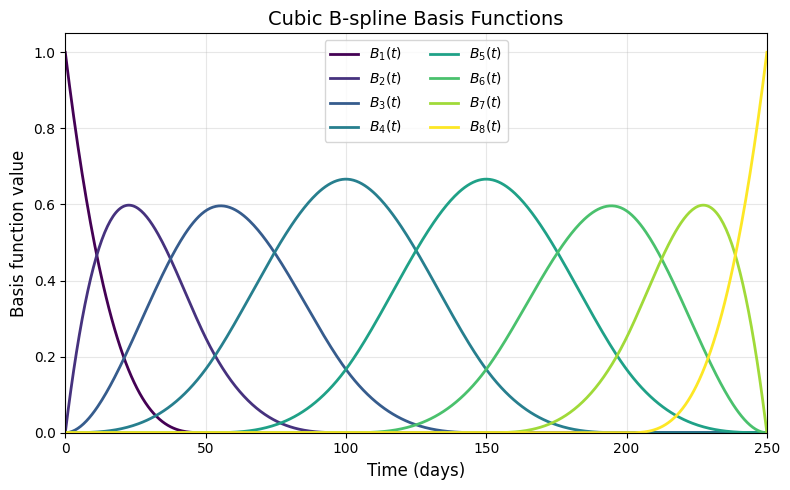

<Figure size 640x480 with 0 Axes>

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.interpolate import BSpline
import os

OUT_DIR="Analysis_plots"
os.makedirs(OUT_DIR,exist_ok=True)

T_max = 250      # days
K = 8            # number of basis functions
degree = 3       # cubic B-spline

# Time axis
t = np.linspace(0, T_max, 500)

# Clamped knot vector
n_interior = K - degree - 1
interior_knots = np.linspace(0, T_max, n_interior + 2)[1:-1]

knots = np.concatenate([
    np.repeat(0.0, degree + 1),
    interior_knots,
    np.repeat(T_max, degree + 1),
])

# Design matrix
B = BSpline.design_matrix(t, knots, degree, extrapolate=True).toarray()


# Plot B-spline basis functions
plt.figure(figsize=(8, 5))

colors = cm.viridis(np.linspace(0, 1, K))

for i in range(K):
    plt.plot(
        t,
        B[:, i],
        lw=2,
        color=colors[i],
        label=fr"$B_{{{i+1}}}(t)$"
    )

plt.xlabel("Time (days)", fontsize=12)
plt.ylabel("Basis function value", fontsize=12)
plt.title("Cubic B-spline Basis Functions", fontsize=14)
plt.xlim(0, T_max)
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend(ncol=2, fontsize=10)
plt.tight_layout()

plt.show()
plt.savefig(os.path.join(OUT_DIR,"fig_bspline_basis_functions.png"), dpi=900, bbox_inches='tight')

#### 2-Component Gaussian Mixture on Pooled Epidemic Peak (log scale)

BIC: 1-component = 3506.7   2-component = 3292.6  (2-component preferred (lower BIC))

Near-extinction component   : mean peak =      548   weight = 83.8%
Established-epidemic component: mean peak =   10,795   weight = 16.2%

Data-driven small/large threshold: peak_I = 4,191  (log10 = 3.622)

Strategy         % small epidemics
NTS                          93.5%
LHS                          81.8%
Uniform-Random               78.7%


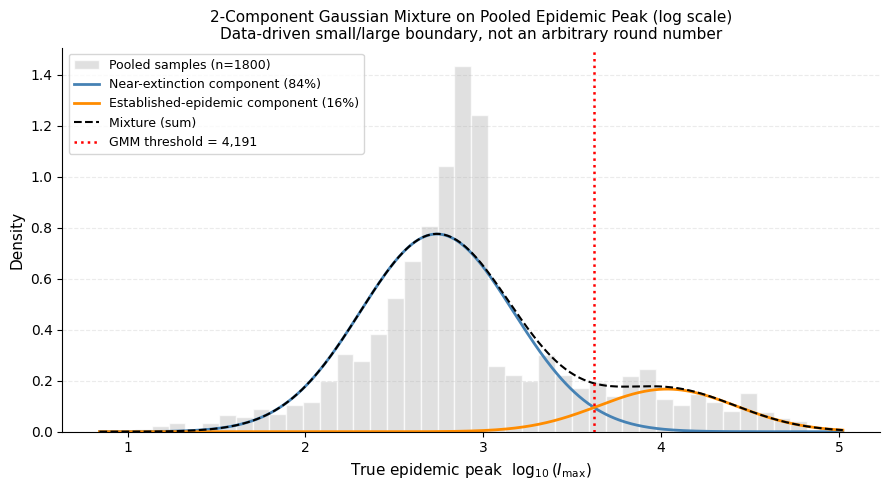

In [ ]:
from sklearn.mixture import GaussianMixture
import os

OUT_DIR="Analysis_plots"
os.makedirs(OUT_DIR, exist_ok=True)

log_peak = np.log10(peak_df['peak_I'].clip(lower=1)).values.reshape(-1, 1)

gmm = GaussianMixture(n_components=2, random_state=0, n_init=100)
gmm.fit(log_peak)

order   = np.argsort(gmm.means_.flatten())
means   = gmm.means_.flatten()[order]
stds    = np.sqrt(gmm.covariances_.flatten())[order]
weights = gmm.weights_.flatten()[order]

# Data-driven threshold: where the two component densities cross
x_grid_fine = np.linspace(log_peak.min(), log_peak.max(), 5000)
resp_low = gmm.predict_proba(x_grid_fine.reshape(-1, 1))[:, order[0]]
gmm_thresh_log = x_grid_fine[np.where(resp_low < 0.5)[0][0]]
gmm_thresh = 10 ** gmm_thresh_log

# Is a 2-component mixture actually justified, or is 1 component enough?
bic1 = GaussianMixture(n_components=1, random_state=0).fit(log_peak).bic(log_peak)
bic2 = gmm.bic(log_peak)

print(f"BIC: 1-component = {bic1:.1f}   2-component = {bic2:.1f}  "
      f"({'2-component preferred (lower BIC)' if bic2 < bic1 else '1-component preferred'})")
print()
print(f"Near-extinction component   : mean peak = {10**means[0]:>8,.0f}   weight = {weights[0]:.1%}")
print(f"Established-epidemic component: mean peak = {10**means[1]:>8,.0f}   weight = {weights[1]:.1%}")
print()
print(f"Data-driven small/large threshold: peak_I = {gmm_thresh:,.0f}  "
      f"(log10 = {gmm_thresh_log:.3f})")
print()
print(f"{'Strategy':16s}{'% small epidemics':>18s}")
for strat in strategies:
    sub = peak_df.loc[peak_df['test_strategy'] == strat, 'peak_I']
    pct_gmm = (np.log10(sub.clip(lower=1)) < gmm_thresh_log).mean() * 100
    print(f"{LABELS[strat]:16s}{pct_gmm:17.1f}%")

# Visualisation
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(log_peak.flatten(), bins=40, density=True, color='lightgrey',
        edgecolor='white', alpha=0.7, label='Pooled samples (n=%d)' % len(log_peak))

x_grid_plot = np.linspace(log_peak.min() - 0.2, log_peak.max() + 0.2, 500)
comp0 = weights[0] * stats.norm.pdf(x_grid_plot, means[0], stds[0])
comp1 = weights[1] * stats.norm.pdf(x_grid_plot, means[1], stds[1])
ax.plot(x_grid_plot, comp0, color='steelblue', lw=2,
        label=f'Near-extinction component ({weights[0]:.0%})')
ax.plot(x_grid_plot, comp1, color='darkorange', lw=2,
        label=f'Established-epidemic component ({weights[1]:.0%})')
ax.plot(x_grid_plot, comp0 + comp1, color='black', lw=1.5, linestyle='--',
        label='Mixture (sum)')

ax.axvline(gmm_thresh_log, color='red', linestyle=':', lw=1.8,
           label=f'GMM threshold = {gmm_thresh:,.0f}')

ax.set_xlabel(r'True epidemic peak  $\log_{10}(I_{\max})$', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title(
    '2-Component Gaussian Mixture on Pooled Epidemic Peak (log scale)',
    fontsize=11
)
ax.legend(fontsize=9)
ax.grid(True, axis='y', alpha=0.25, linestyle='--')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()
plt.savefig(os.path.join(OUT_DIR,"GaussianMixture.png"),dpi=900,bbox_inches="tight")


test_strategy    train_strategy    mean R2_I
LHS              LHS               0.946
                 MCMC              0.667   ← collapse
                 UNIFORM_RANDOM    0.949
UNIFORM_RANDOM   LHS               0.949
                 MCMC              0.682   ← collapse
                 UNIFORM_RANDOM    0.950
MCMC             LHS               0.894
                 MCMC               0.859
                 UNIFORM_RANDOM    0.898


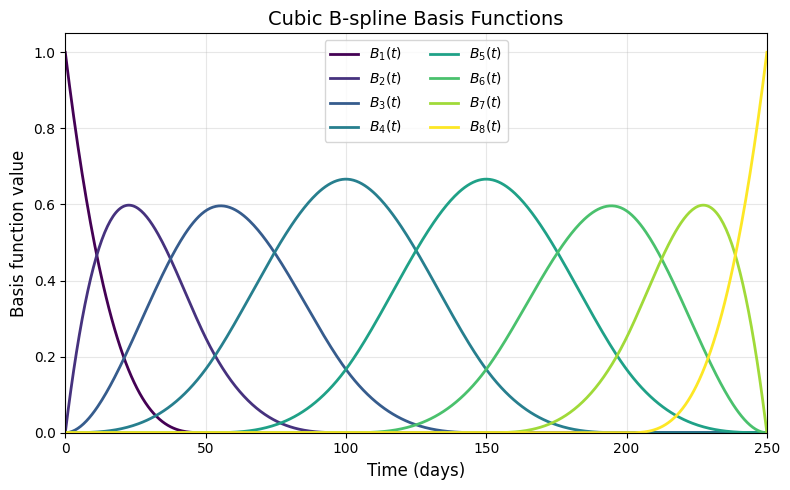

<Figure size 640x480 with 0 Axes>

### Computaional time using a heat map

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import os

import pandas as pd
OUT_DIR = "Analysis_plots"
os.makedirs(OUT_DIR, exist_ok=True)

data = pd.DataFrame({
    'parameter_sampling_time': [0.082, 2.14,0.029],
    'simulation_time(per simulation)': [ 0.00046, 0.00025, 0.00046],
    'Time_all_sim (parameter sampling + simulation_All_sim)': [ 18.42, 12.14, 17.88],
    'training_time per rep (with aug)': [2.51, 1.70, 2.66],
    'training_time per rep (no augmetation)': [0.87, 0.70, 0.92],
    'Total_time_all_sim(aug)': [43.42,29.11 ,44.46],
    'Total_time_all_sim(no aug)': [26.7, 19.14, 27.06]
}, index=['LHS', 'NTS', 'Uniform-Random'])

plt.figure(figsize=(8, 6))

sns.heatmap(
    data,
    annot=True,
    cmap='Reds',
    linewidths=0.5,
    fmt=""
)



plt.title("Computation Time Comparison Across Sampling Strategies in Minutes")
plt.ylabel("Sampling trategy")
plt.xlabel("Metrics")
plt.savefig(os.path.join(OUT_DIR,"computational_time_comparison.png"),dpi=900,bbox_inches="tight")
plt.show()